**Application of BERTopic on Pro-Choice Classifications**

In [ ]:
!pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn pandas matplotlib
from bertopic import BERTopic
import pandas as pd
import textwrap

import torch
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from bertopic import BERTopic

import os

  Using cached bertopic-0.16.4-py3-none-any.whl.metadata (23 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached bertopic-0.16.4-py3-none-any.whl (143 kB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl (207.5 MB)
  Attempting uninstall: nvidia-cudnn-cu12
    Found existing installation: nvidia-cudnn-cu12 9.3.0.75
    Uninstalling nvidia-cudnn-cu12-9.3.0.75:
      Successfully uninstalled nvidia-cudnn-cu12-9.3.0.75
  Attempting uninstall: nvidia-cusolver-cu12
    Found existing installation: nvidia-cusolver-cu12 11.6.3.83
    Uninstall

In [ ]:
print("GPU Available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

GPU Available: True


In [ ]:
data = pd.read_csv('highconf_label_data.csv')

cat = 1.0

data = data[data['label'] == cat]
data = data.dropna(subset=['body']).reset_index(drop=True)

data = data['body'].to_list()

In [ ]:
hdbscan_model = HDBSCAN(min_cluster_size=40,  # min cluster size before it can become its own
                        min_samples=15,       # how many neighbors it has before its part of a clsuter
                        cluster_selection_epsilon=0.1,
                        metric="euclidean",
                        prediction_data=True)

In [ ]:
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
topic_model = BERTopic(embedding_model=embedding_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       verbose=True)
topics, probs = topic_model.fit_transform(data)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7929,-1_abortion_women_life_pro,"[abortion, women, life, pro, people, woman, fe...","[that needs a source, and it's certainly not c..."
1,0,672,0_thank_oh_lol_link,"[thank, oh, lol, link, good, read, article, kn...","[what? so do you lol, oh no! anyway., thank ..."
2,1,495,1_vote_democrat_party_democrats,"[vote, democrat, party, democrats, biden, vote...","[in a general election that is. of course, bot..."
3,2,486,2_republicans_women_gop_abortion,"[republicans, women, gop, abortion, republican...",[republicans want to leave us alone. the rep...
4,3,465,3_blood_body_donate_kidney,"[blood, body, donate, kidney, person, autonomy...",[nothing has a right to use your body. even to...
5,4,304,4_rights_fetus_person_body,"[rights, fetus, person, body, right, mother, a...",[you didnt read what i wrote if you dont think...
6,5,298,5_forced_forced birth_birth_birth forced,"[forced, forced birth, birth, birth forced, to...","[forced birth, that or forced birth, forced bi..."
7,6,268,6_religious_abortion_religion_people,"[religious, abortion, religion, people, life, ...",[thank you for your respectful reply. ive resp...
8,7,223,7_rape_raped_woman_forced,"[rape, raped, woman, forced, rapist, child, ba...",[you definitely get points for noting that for...
9,8,216,8_state_states_abortion_travel,"[state, states, abortion, travel, women, ban, ...","[from the article: ""house bill 242, which pas..."


In [ ]:
topic_labels = topic_model.get_topic_info()

In [ ]:
# similar things we saw in pl with -1..
general_abort = [data[i] for i, topic in enumerate(topics) if topic == -1]

for i, doc in enumerate(general_abort[:10]):
  print(f'{i}:: {doc}')
  print("")

0:: to be clear. . for me personally. . .life is sacred.  i have never needed to make that decision and i am so glad i did not. what would i have done? i don't know. i do know that the decision would have haunted me forever. right or wrong i think most women do not view it lightly.   my question to you. . .if a woman views a pregnancy as a burden, one that she tried everything she could think of to get rid of naturally and yet remained pregnant. are you going to protect that child so its existence is not hell on earth? many children are born into situations where they wish they had never been born.  would more unwanted children help anyone? if life is so sacred why do we not treat people, who are already here, better?  basically this issue comes under the 'shoulda never been anyone else's business but my own' . . .now that it is a government issue, it makes it way more complicated. if you don't have a uterus. . it is not your issue.

1:: no, you don't seem to get my logic, because that

In [ ]:
topic_embeddings = topic_model.topic_embeddings_
similarity_matrix = cosine_similarity(topic_embeddings)

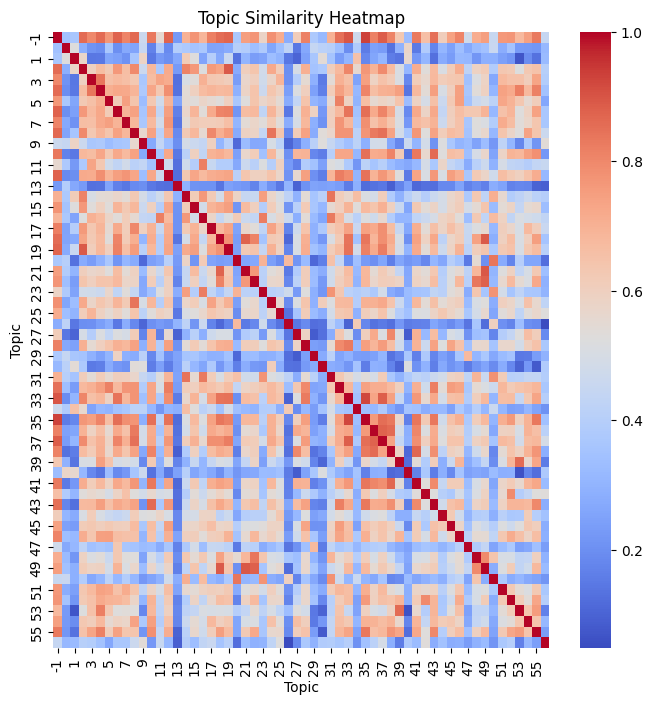

In [ ]:
topic_sim_df = pd.DataFrame(similarity_matrix,
                            index=topic_model.get_topic_info()["Topic"],
                            columns=topic_model.get_topic_info()["Topic"])


plt.figure(figsize=(8, 8))
sns.heatmap(topic_sim_df, cmap="coolwarm", annot=False)
plt.title("Topic Similarity Heatmap")
plt.show()


In [ ]:
topic_embeddings = topic_model.topic_embeddings_
similarity_matrix = cosine_similarity(topic_embeddings)

topic_sim_df = pd.DataFrame(similarity_matrix)

similar_pairs = set()
for i in range(len(topic_sim_df)):
    for j in range(i + 1, len(topic_sim_df)):
        if similarity_matrix[i, j] > 0.9:
            similar_pairs.add((i, j, similarity_matrix[i, j]))

similar_pairs = sorted(similar_pairs, key=lambda x: x[2], reverse=True)

print(len(similar_pairs))

similar_pairs

# this one only has 2 at .9!!

2


[(0, 36, 0.9302465), (34, 36, 0.9245998)]

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info[topic_info['Topic'] == 0]

,Topic,Count,Name,Representation,Representative_Docs
1,0,672,0_thank_oh_lol_link,"[thank, oh, lol, link, good, read, article, kn...","[what? so do you lol, oh no! anyway., thank ..."


In [ ]:
topic_info[topic_info['Topic'] == 36]

,Topic,Count,Name,Representation,Representative_Docs
37,36,78,36_trans_rights_women_men,"[trans, rights, women, men, reproductive right...",[reproductive rights are often said to be the ...


In [ ]:
labels = {
    -1: 'Less structured abortion discourse',
    0: 'links',
    1: 'Voting, Elections',
    2: 'Anti-Republican Discussion',
    3: 'Body Autonomy',
    4: 'Body Autonomy',
    5: 'Forced Birth',
    6: 'Separation of Religion and Politics in Abortion Debate',
    7: 'Rape as an Exception',
    8: 'State Laws and Restrictions',
    9: 'Supreme Court and Legal Topics',
    10: 'Medical Issues, Miscarriages Eptopic Preg',
    11: 'Body Autonomy',
    12: 'Gender dyanmics and inequalities',
    13: 'Comparisions to Handmaids Tale',
    14: 'Politics of Control',
    15: 'Pro Choice, Abortion Access',
    16: 'Body Autonomy',
    17: 'Roe v Wade',
    18: 'Pro-Choice discussions',
    19: 'Politics of Control',
    20: 'Women',
    21: 'Pro Choice disussions',
    22: '"Pro birth not pro life" discussion (Critiques of prolife?)',
    23: 'Politics of Control',
    24: 'State Laws and Restrictions',
    25: 'Body Autonomy (Vaccines)',
    26: 'Women',
    27: 'The Realities of Early Detection (6 week ban)',
    28: 'Birth Control',
    29: 'Religion',
    30: 'State Laws and Restrictions',
    31: 'Trans rights',
    32: 'Politics of Control',
    33: 'Politics of Control',
    34: 'Voting, Elections, Politicans',
    35: 'Emotional Burden and Decision-Making in Abortion',
    36: 'Other countrys abortion laws',
    37: 'Abortion Ban',
    38: '(week) abortion ban (various weeks)',
    39: 'Fetus is not a person',
    40: 'Speaking about other countries, unrelate to abortion',
    41: 'late term abortion',
    42: 'hypocriasy abortion and death penalty',
    43: 'Medical Risks',
    44: 'Medical Ethics (Privacy)',
    45: 'Vasectomies (possibly gender?)',
    46: '"Pro birth not pro life" discussion (Critiques of prolife?)',
    47: 'Separation of Religion and Politics in Abortion Debate',
    48: 'Pro life is anti women',
    49: 'Pro life is anti choice',
    50: 'Anti women',
    51: 'Abortion and Slavery (critiques)',
    52: 'murder, killing babies (responses?)',
    53: 'Fetus as a Separate Entity (seems prolife)',
    54: 'Heartbeat laws',
    55: 'Defining Human Life in Abortion Debate (life doesnt begin at conception)',
    56: 'Guns',

}

In [ ]:
labels = {
    # Politics of Control
    19: 'Politics of Control',
    23: 'Politics of Control',
    14: 'Politics of Control',
    32: 'Politics of Control',
    33: 'Politics of Control',

    # Body Autonomy
    3: 'Body Autonomy',
    4: 'Body Autonomy',
    11: 'Body Autonomy',
    25: 'Body Autonomy (Vaccines)',
    16: 'Body Autonomy',

    # State Laws and Restrictions
    8: 'State Laws and Restrictions',
    24: 'State Laws and Restrictions',
    30: 'State Laws and Restrictions',

    # Religious Influence
    6: 'Separation of Religion and Politics in Abortion Debate',
    29: 'Religion',

    # Pro-Choice Discussions
    15: 'Pro Choice discussion',
    18: 'Pro-Choice discussions',
    21: 'Pro Choice discussions',

    # "Pro birth not pro life" Discussion (Critiques of Pro-life)
    22: '"Pro birth not pro life" discussion (Critiques of prolife?)',
    46: '"Pro birth not pro life" discussion (Critiques of prolife?)',

    # Women
    20: 'Women',
    26: 'Women',

    # Medical Risks
    10: 'Medical Issues, Miscarriages Ectopic Preg',
    43: 'Medical Risks',

    # Abortion Bans
    27: 'The Realities of Early Detection (6 week ban)',
    37: 'Abortion Ban',
    38: '(week) abortion ban (various weeks)',
    54: 'Heartbeat bans/laws',

    # Abortion and Slavery
    51: 'Abortion and Slavery (critiques)',

    # Voting
    1: 'Voting, Elections',
    34: 'Voting, Elections, Politicians',


    # DEFINING Personhood (Pro-Choice?)
    55: 'Defining Human Life in Abortion Debate (life doesnt begin at conception)',
    39: 'Fetus is not a person',

    # Pro-Life Critiques (Grouped)
    48: 'Pro life is anti women',
    49: 'Pro life is anti choice',
    50: 'Anti women',

    # Other Labels, ungrouped
    7: 'Rape as an Exception',
    9: 'Supreme Court and Legal Topics',
    12: 'Gender dynamics and inequalities',
    13: 'Comparisons to Handmaids Tale',
    17: 'Roe v Wade',
    40: 'Speaking about other countries, unrelated to abortion',
    41: 'Late term abortion',
    42: 'Hypocrisy abortion and death penalty',
    44: 'Medical Ethics (Privacy)',
    45: 'Vasectomies (possibly gender?)',
     52: 'Murder, killing babies (responses?)',
    56: 'Guns',
    -1: 'Less structured abortion discourse',
    0: 'links',



}


In [ ]:
wrap_width = 100

rep_docs = topic_model.get_representative_docs()
topic_keywords = topic_model.get_topics()

topic_id = 7
for word in topic_keywords[topic_id]:
    print(word[0])

for comment in rep_docs[topic_id][:2]:
    wrapped_comment = textwrap.fill(comment, width=wrap_width)
    print(f"- {wrapped_comment}\n")


religious
abortion
religion
people
life
christian
bible
beliefs
don
god
- that is what the traditional anti-abortion movement is at its core: controlling women (aka misogyny)
and setting the value of an unborn above a woman (its funny how it doesnt affect men, right?) none
of them want to help with contraceptives, sex education, providing parents with decent resources in
the society etc. all they want is to force women to have unwanted children, abandon said children
and mothers, and move onto the next woman.   anti-abortion movement (in us the right to life
movement) came from fundamentalist christians (the us movement found by american catholics) and its
quite new if you look at it from a historical viewpoint. and when you look at the bible there is
absolutely nothing forbidding abortion really, in fact there is even a recipe for abortion if a
child has been conceived in an extramarital affair and it is the husbands duty to abort the fetus
inside his wife.   you can be pro-life as in

In [ ]:
topics_to_merge = [
    [19, 23, 14, 32, 33],  # Politics of Control
    [3, 4, 11, 25, 16],  # Body Autonomy
    [8, 24, 30],  # State Laws and Restrictions
    [6, 29],  # Religious Influence
    [15, 18, 21],  # Pro-Choice Discussions
    [22, 46],  # "Pro birth not pro life" Discussion (Critiques of Pro-life)
    [20, 26],  # Women
    [10, 43],  # Medical Risks
    [27, 37, 38, 54],  # Abortion Bans
    [1, 34],  # Voting
    [48, 49, 50],  # Pro-Life Critiques (Grouped)
]

topic_model.merge_topics(data, topics_to_merge)

topic_info = topic_model.get_topic_info()


In [ ]:
print(os.path.exists("/content/drive/MyDrive/Colab Notebooks/prochoice_berttopic"))


True


In [ ]:
drive.mount('/content/drive')

topic_model = BERTopic.load("/content/drive/MyDrive/Colab Notebooks/prochoice_berttopic")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7929,-1_abortion_women_life_pro,"[abortion, women, life, pro, people, woman, fe...","[pro-choicers have been hashing these ""ethical..."
1,0,1227,0_autonomy_body_bodily_bodily autonomy,"[autonomy, body, bodily, bodily autonomy, righ...",[that is not what bodily autonomy means. the ...
2,1,672,1_thank_oh_link_lol,"[thank, oh, link, lol, good, read, know, artic...","[link ?, oh no! anyway., *""oh no!! what will..."
3,2,617,2_women_want_conservatives_control,"[women, want, conservatives, control, abortion...","[women want to control other women., to own wo..."
4,3,586,3_vote_democrat_party_democrats,"[vote, democrat, party, democrats, biden, trum...",[this is why it's important to push back again...
5,4,486,4_republicans_women_abortion_gop,"[republicans, women, abortion, gop, want, repu...",[republicans want to leave us alone. the rep...
6,5,461,5_pro_pro choice_choice_abortion,"[pro, pro choice, choice, abortion, pro aborti...","[and that is being pro choice., again, pro cho..."
7,6,417,6_texas_state_abortion_states,"[texas, state, abortion, states, women, ban, a...","[first, the types of people who support the le..."
8,7,367,7_religious_abortion_religion_people,"[religious, abortion, religion, people, life, ...",[that is what the traditional anti-abortion mo...
9,8,305,8_weeks_pregnancy_pregnant_abortion,"[weeks, pregnancy, pregnant, abortion, period,...","[you, like many gop politicians, don't underst..."


Still seems to be sims, but I can merge manually. need to look more at 1.


In [ ]:
topics_to_merge = [
    [23, 33]]

topic_model.merge_topics(data, topics_to_merge)

topic_info = topic_model.get_topic_info()

In [ ]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7929,-1_abortion_women_life_pro,"[abortion, women, life, pro, people, woman, fe...","[pro-choicers have been hashing these ""ethical..."
1,0,1227,0_autonomy_body_bodily_bodily autonomy,"[autonomy, body, bodily, bodily autonomy, righ...",[that is not what bodily autonomy means. the ...
2,1,672,1_thank_oh_link_lol,"[thank, oh, link, lol, good, read, know, artic...","[link, oh no! anyway., *""oh no!! what will we..."
3,2,617,2_women_want_conservatives_control,"[women, want, conservatives, control, abortion...","[women want to control other women., to own wo..."
4,3,586,3_vote_democrat_party_democrats,"[vote, democrat, party, democrats, biden, trum...",[this is why it's important to push back again...
5,4,486,4_republicans_women_abortion_gop,"[republicans, women, abortion, gop, want, repu...",[republicans have tried to pass hundreds of la...
6,5,461,5_pro_pro choice_choice_abortion,"[pro, pro choice, choice, abortion, pro aborti...","[and that is being pro choice., again, pro cho..."
7,6,417,6_texas_state_abortion_states,"[texas, state, abortion, states, women, ban, a...","[first, the types of people who support the le..."
8,7,367,7_religious_abortion_religion_people,"[religious, abortion, religion, people, life, ...",[that is what the traditional anti-abortion mo...
9,8,305,8_weeks_pregnancy_pregnant_abortion,"[weeks, pregnancy, pregnant, abortion, period,...","[you, like many gop politicians, don't underst..."


In [ ]:
labels = {
    0: "Bodily Autonomy",
    1: "Sharing Resources and Information",
    2: "Politics of Control (Government Control and Policy)",
    3: "Elections, Voting, and Political Influence",
    4: "Criticism of Republican Policies",
    5: "General Pro-Choice Discussions",
    6: "State-Level Abortion Laws and Restrictions",
    7: "Religion’s Role in Abortion Debates",
    8: "Early Pregnancy Detection and Abortion Bans",
    9: "Forced Birth and Reproductive Coercion",
    10: "Health Risks and Medical Considerations",
    11: "Women’s Rights and Gender Equality",
    12: "Rape Exceptions in Abortion Laws",
    13: "Supreme Court Decisions and Legal Debates",
    14: "Gender Dynamics and Inequalities",
    15: "Criticism of Pro-Life: 'Pro-Birth, Not Pro-Life'",
    16: "Handmaid’s Tale Comparisons",
    17: "Pro-Life and Anti-Choice Perspectives",
    18: "Roe v. Wade and Its Impact",
    19: "Birth Control and Contraceptive Access",
    20: "Trans Rights and Abortion (Unrelated)",
    21: "Emotional Burden and Decision-Making in Abortion",
    22: "Abortion Ban Timelines and Viability Limits",
    23: "Defining Personhood in Abortion Debate (Pro-Choice Perspective)",
    24: "International Perspectives on Abortion",
    25: "Late-Term Abortion Discussions",
    26: "Hypocrisy in Abortion and Death Penalty Debates",
    27: "Medical Ethics and Privacy Concerns",
    28: "Vasectomies, Gender, and Reproductive Responsibilities",
    29: "Religious Influence on Abortion Laws",
    30: "Critiques Comparing Abortion Restrictions to Slavery",
    31: "Murder and Killing Rhetoric in Abortion Debate",
    32: "Pro-Life Discussions and Arguments",
    33: "Defining Human Life in Abortion Debate (Challenging 'Life Begins at Conception')",
    34: "Gun Rights vs. Abortion Rights Comparisons"
}


topic_info["Topic Label"] = topic_info["Topic"].map(labels)


In [ ]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs,Topic Label
0,-1,7929,-1_abortion_women_life_pro,"[abortion, women, life, pro, people, woman, fe...","[pro-choicers have been hashing these ""ethical...",NaN
1,0,1227,0_autonomy_body_bodily_bodily autonomy,"[autonomy, body, bodily, bodily autonomy, righ...",[that is not what bodily autonomy means. the ...,Bodily Autonomy and Reproductive Rights
2,1,672,1_thank_oh_link_lol,"[thank, oh, link, lol, good, read, know, artic...","[link, oh no! anyway., *""oh no!! what will we...",Sharing Resources and Information
3,2,617,2_women_want_conservatives_control,"[women, want, conservatives, control, abortion...","[women want to control other women., to own wo...",Government Control and Policy
4,3,586,3_vote_democrat_party_democrats,"[vote, democrat, party, democrats, biden, trum...",[this is why it's important to push back again...,"Elections, Voting, and Political Influence"
5,4,486,4_republicans_women_abortion_gop,"[republicans, women, abortion, gop, want, repu...",[republicans have tried to pass hundreds of la...,Criticism of Republican Policies
6,5,461,5_pro_pro choice_choice_abortion,"[pro, pro choice, choice, abortion, pro aborti...","[and that is being pro choice., again, pro cho...",General Pro-Choice Discussions
7,6,417,6_texas_state_abortion_states,"[texas, state, abortion, states, women, ban, a...","[first, the types of people who support the le...",State-Level Abortion Laws and Restrictions
8,7,367,7_religious_abortion_religion_people,"[religious, abortion, religion, people, life, ...",[that is what the traditional anti-abortion mo...,Religion’s Role in Abortion Debates
9,8,305,8_weeks_pregnancy_pregnant_abortion,"[weeks, pregnancy, pregnant, abortion, period,...","[you, like many gop politicians, don't underst...",Early Pregnancy Detection and Abortion Bans


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

topic_model.save('/content/drive/MyDrive/prochoice_berttopic')

In [ ]:
topics = topic_model.get_topics()
topics

{-1: [('abortion', 0.013857394413752775),
  ('women', 0.01288277963185055),
  ('life', 0.011005794977863971),
  ('pro', 0.009945781501736042),
  ('people', 0.009856617836725727),
  ('woman', 0.00972366362448997),
  ('fetus', 0.009597891914116731),
  ('choice', 0.008875535918328924),
  ('abortions', 0.008741434721474555),
  ('want', 0.008685453851871876)],
 0: [('autonomy', 0.028248012542763355),
  ('body', 0.02686613140765734),
  ('bodily', 0.02558617330688669),
  ('bodily autonomy', 0.024793324323452555),
  ('right', 0.021240953077055823),
  ('person', 0.02095085677477212),
  ('fetus', 0.01944697587840214),
  ('rights', 0.018262022235279764),
  ('blood', 0.01572509311613358),
  ('donate', 0.014454707588740597)],
 1: [('thank', 0.019640481571766632),
  ('oh', 0.019526174088598292),
  ('link', 0.018334958451618685),
  ('lol', 0.017798340762617895),
  ('good', 0.017402576697038787),
  ('read', 0.0151185788572754),
  ('know', 0.012438107511584227),
  ('article', 0.011555427795503977),
  (

In [ ]:
# from Sade on stackoverflow : https://stackoverflow.com/questions/76235208/evaluating-a-bertopic-model-based-on-classification-metrics
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim import corpora

def calculate_coherence_score(topic_model, docs):
    # Preprocess documents
    cleaned_docs = topic_model._preprocess_text(docs)

    # Extract vectorizer and tokenizer from BERTopic
    vectorizer = topic_model.vectorizer_model
    tokenizer = vectorizer.build_tokenizer()

    # Extract features for Topic Coherence evaluation
    words = vectorizer.get_feature_names_out()
    # depending on the version and if you get an error use commented out code below:
    # words = vectorizer.get_feature_names()
    tokens = [tokenizer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    # Create topic words
    topic_words = [[dictionary.token2id[w] for w in words if w in dictionary.token2id]
    for _ in range(len(topic_model.get_topics()))]

    # this creates a list of the token ids (in the format of integers) of the words in words that are also present in the
    # dictionary created from the preprocessed text. The topic_words list contains list of token ids for each
    # topic.

    coherence_model = CoherenceModel(topics=topic_words,
                                    texts=tokens,
                                    corpus=corpus,
                                    dictionary=dictionary,
                                    coherence='c_v')
    coherence = coherence_model.get_coherence()

    return coherence

calculate_coherence_score(topic_model, data)

0.5739929741385704

!pip install gensim


In [ ]:
len(topic_model.get_topics())

35

**EDA on -1**

In [ ]:
general_discourse_docs = [data[i] for i, topic in enumerate(topics) if topic == -1]

sub_topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

sub_topics, sub_probs = sub_topic_model.fit_transform(general_discourse_docs)

In [ ]:
sub_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,393,-1_life_baby_babies_killing,"[life, baby, babies, killing, child, murder, u...",[i don't really care what your interpretation ...
1,0,3427,0_life_human_abortion_murder,"[life, human, abortion, murder, baby, child, k...","[first, you know that godwin's law is just a m..."
2,1,54,1_religion_innocents_god_people,"[religion, innocents, god, people, murder, inn...","[you are correct sir, the people preaching fro..."
3,2,24,2_catholic_penalty_abortion_death penalty,"[catholic, penalty, abortion, death penalty, c...","[catholic here - i'm not defending this, just ..."
4,3,24,3_syndrome_downs_people_downs syndrome,"[syndrome, downs, people, downs syndrome, chil...",[there are a significant number of charitable ...
5,4,24,4_heartbeat_heart_human_baby,"[heartbeat, heart, human, baby, life, baby hea...",[what does a heart beat have to do with anythi...


- breaking down large -1 gave me 5 more topics, repeated the process:


In [ ]:
rep_docs = sub_topic_model.get_representative_docs()
topic_keywords = sub_topic_model.get_topics()

topic_id = 1

for word in topic_keywords[topic_id]:
  print(word[0])

for comment in rep_docs[topic_id][:5]:
  print(f"- {comment}\n")


religion
innocents
god
people
murder
innocent
religious
bible
killing
murdering
- you are correct sir, the people preaching from the pulpit that human life is sacred are the same ones saying you must murder the doctors, and also supporting the endless war overseas against the non-christians that results in the mass slaughter of millions of innocents.  but let's face it- when was religious zealotry ever about being intelligent, logical, or truthful? hypocritical mass murder of the innocent has ever been their strong card. the church is hungry *it must be fed with lives!* either by murdering the heretic and stealing their land and posessions, or making your flock being as fruitful as possible so you can collect tithes on their labor.

- id like to believe youre interested in looking into this is good faith, but my suspicions doubt it. but hell, ill take the bait anyways.  leviticus 25:44-46 god has a chance to condone slavery but doesnt. exodus 21:20-21 gods instructions on acceptable be

Interesting that this is (seemingly) PC opinons that have co-opted religiousity and using it to point point out the hypocrisy. Almost like the body autonomy topic in PL.

In [ ]:
topic_embeddings_main = topic_model.topic_embeddings_
topic_embeddings_sub = sub_topic_model.topic_embeddings_

similarity_matrix = cosine_similarity(topic_embeddings_sub, topic_embeddings_main)

similarity_df = pd.DataFrame(similarity_matrix,
                             index=sub_topic_model.get_topic_info()['Topic'],
                             columns=topic_model.get_topic_info()['Topic'])

top_matches = similarity_df.idxmax(axis=1)
top_matches[:10]

,0
Topic,
-1,-1
0,-1
1,16
2,0
3,21
4,-1
